<a href="https://colab.research.google.com/github/jak0110/Group-6-Project/blob/main/GISC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the path to the file you'd like to load
# The previous error indicated that 'spotify_tracks.csv' was not present.
# Based on the available files, 'dataset.csv' is likely the correct file within the dataset.
file_path = "dataset.csv"

# Load the latest version of the dataset
try:
  df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "maharshipandya/-spotify-tracks-dataset",
    file_path
  )
  print(f"Dataset '{file_path}' loaded successfully. First 5 rows:\n")
  display(df.head())
except Exception as e:
  print(f"Error loading dataset: {e}")
  print("Please ensure the dataset 'maharshipandya/-spotify-tracks-dataset' is available and 'dataset.csv' (or the correct filename) is the correct file path.")

/tmp/ipykernel_256/414754408.py:14: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Dataset 'dataset.csv' loaded successfully. First 5 rows:



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


Now, let's filter the data for `modality == 1` and create a 10-bin histogram of 'popularity'.

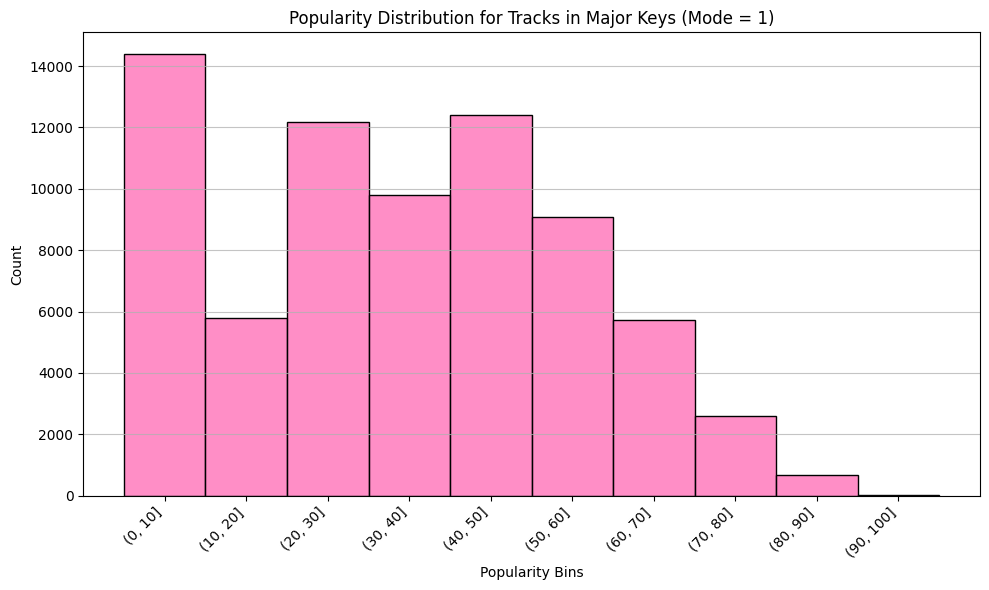

In [ ]:
# Filter the DataFrame for items where 'mode' is 1
if 'df' in locals() and not df.empty:
  filtered_df = df[df['mode'] == 1]

  # Check if there's data after filtering
  if not filtered_df.empty:
    # Create a 10-bin histogram of 'popularity'
    plt.figure(figsize=(10, 6))

    # Calculate bin edges using numpy.histogram to ensure we have the exact bins sns.histplot will use
    import numpy as np
    hist_values, bin_edges = np.histogram(filtered_df['popularity'], bins=10)

    # Plot the histogram using the calculated bin_edges
    sns.histplot(filtered_df['popularity'], bins=bin_edges, kde=False, color='#FF69B4') # Changed color to pink

    plt.title('Popularity Distribution for Tracks in Major Keys (Mode = 1)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.75)

    # Format the x-axis labels with open parentheses and closed brackets notation
    bin_labels = []
    for i in range(len(bin_edges) - 1):
        # Format as (lower, upper]. Use .0f to avoid decimals if popularity is integer-like.
        bin_labels.append(f"({bin_edges[i]:.0f}, {bin_edges[i+1]:.0f}]")

    # Set x-ticks at the center of each bin for better label alignment with the bars
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    plt.xticks(bin_centers, bin_labels, rotation=45, ha='right')
    plt.xlabel('Popularity Bins') # Change xlabel to reflect bins

    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
  else:
    print("No data found for 'mode == 1'. Cannot generate histogram.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Now, let's create a histogram for items where `mode == 0` (minor keys) using the same styling.

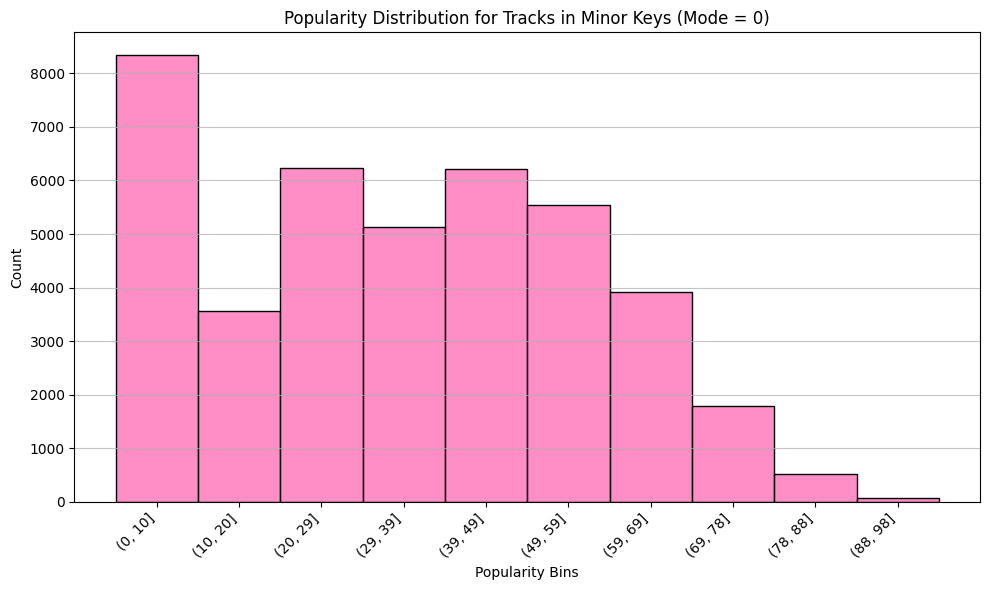

In [ ]:
# Filter the DataFrame for items where 'mode' is 0
if 'df' in locals() and not df.empty:
  filtered_df_mode_0 = df[df['mode'] == 0]

  # Check if there's data after filtering
  if not filtered_df_mode_0.empty:
    # Create a 10-bin histogram of 'popularity'
    plt.figure(figsize=(10, 6))

    # Calculate bin edges using numpy.histogram to ensure we have the exact bins sns.histplot will use
    import numpy as np
    hist_values_mode_0, bin_edges_mode_0 = np.histogram(filtered_df_mode_0['popularity'], bins=10)

    # Plot the histogram using the calculated bin_edges
    sns.histplot(filtered_df_mode_0['popularity'], bins=bin_edges_mode_0, kde=False, color='#FF69B4') # Pink color

    plt.title('Popularity Distribution for Tracks in Minor Keys (Mode = 0)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.75)

    # Format the x-axis labels with open parentheses and closed brackets notation
    bin_labels_mode_0 = []
    for i in range(len(bin_edges_mode_0) - 1):
        # Format as (lower, upper]. Use .0f to avoid decimals if popularity is integer-like.
        bin_labels_mode_0.append(f"({bin_edges_mode_0[i]:.0f}, {bin_edges_mode_0[i+1]:.0f}]")

    # Set x-ticks at the center of each bin for better label alignment with the bars
    bin_centers_mode_0 = (bin_edges_mode_0[:-1] + bin_edges_mode_0[1:]) / 2
    plt.xticks(bin_centers_mode_0, bin_labels_mode_0, rotation=45, ha='right')
    plt.xlabel('Popularity Bins') # Change xlabel to reflect bins

    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
  else:
    print("No data found for 'mode == 0'. Cannot generate histogram.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Let's generate the histogram for tracks in major keys (mode = 1), excluding tracks with popularity zero, and using a lilac color.

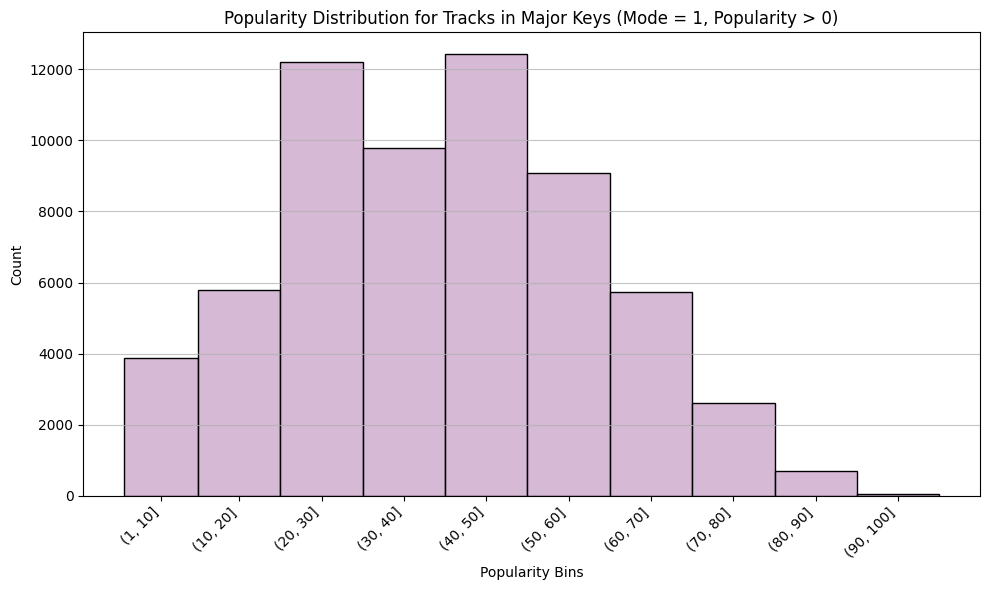

In [ ]:
# Filter the DataFrame for items where 'mode' is 1 AND popularity is greater than 0
if 'df' in locals() and not df.empty:
  filtered_df_mode_1_no_zero = df[(df['mode'] == 1) & (df['popularity'] > 0)]

  # Check if there's data after filtering
  if not filtered_df_mode_1_no_zero.empty:
    # Create a 10-bin histogram of 'popularity'
    plt.figure(figsize=(10, 6))

    # Define custom bin edges: first bin (1,10], then uniform bins up to 100
    custom_bins = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    # Calculate bin edges using numpy.histogram to ensure we have the exact bins sns.histplot will use
    import numpy as np
    hist_values_mode_1_no_zero, bin_edges_mode_1_no_zero = np.histogram(filtered_df_mode_1_no_zero['popularity'], bins=custom_bins)

    # Plot the histogram using the calculated bin_edges
    sns.histplot(filtered_df_mode_1_no_zero['popularity'], bins=bin_edges_mode_1_no_zero, kde=False, color='#C8A2C8') # Lilac color

    plt.title('Popularity Distribution for Tracks in Major Keys (Mode = 1, Popularity > 0)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.75)

    # Format the x-axis labels with open parentheses and closed brackets notation
    bin_labels_mode_1_no_zero = []
    for i in range(len(bin_edges_mode_1_no_zero) - 1):
        # Format as (lower, upper]. Use .0f to avoid decimals if popularity is integer-like.
        bin_labels_mode_1_no_zero.append(f"({bin_edges_mode_1_no_zero[i]:.0f}, {bin_edges_mode_1_no_zero[i+1]:.0f}]")

    # Set x-ticks at the center of each bin for better label alignment with the bars
    bin_centers_mode_1_no_zero = (bin_edges_mode_1_no_zero[:-1] + bin_edges_mode_1_no_zero[1:]) / 2
    plt.xticks(bin_centers_mode_1_no_zero, bin_labels_mode_1_no_zero, rotation=45, ha='right')
    plt.xlabel('Popularity Bins') # Change xlabel to reflect bins

    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
  else:
    print("No data found for 'mode == 1' and 'popularity > 0'. Cannot generate histogram.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Now, let's generate the histogram for tracks in minor keys (mode = 0), excluding tracks with popularity zero, and using a lilac color.

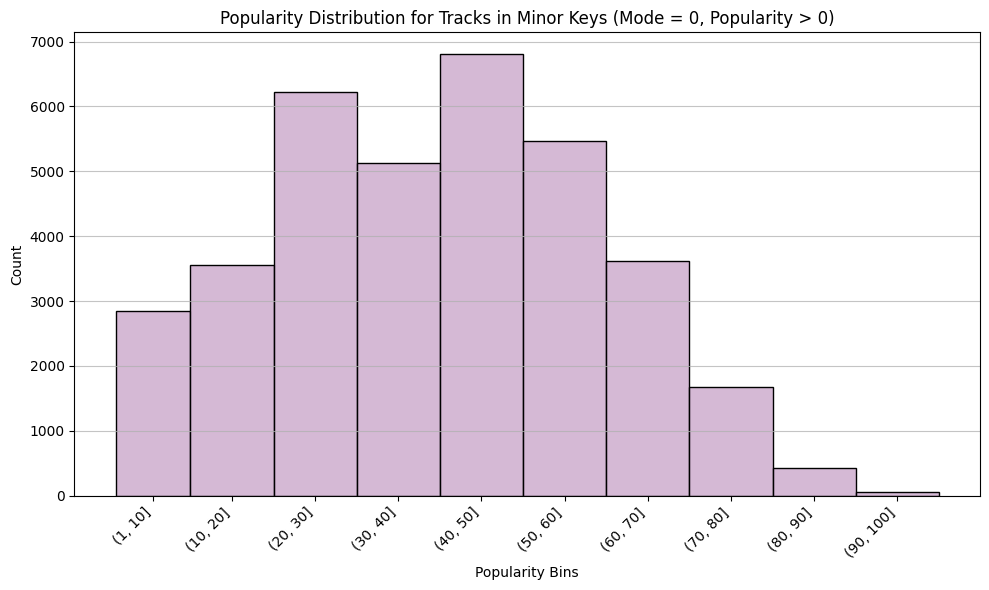

In [ ]:
# Filter the DataFrame for items where 'mode' is 0 AND popularity is greater than 0
if 'df' in locals() and not df.empty:
  filtered_df_mode_0_no_zero = df[(df['mode'] == 0) & (df['popularity'] > 0)]

  # Check if there's data after filtering
  if not filtered_df_mode_0_no_zero.empty:
    # Create a 10-bin histogram of 'popularity'
    plt.figure(figsize=(10, 6))

    # Define custom bin edges: first bin (1,10], then uniform bins up to 100
    custom_bins = [1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

    # Calculate bin edges using numpy.histogram to ensure we have the exact bins sns.histplot will use
    import numpy as np
    hist_values_mode_0_no_zero, bin_edges_mode_0_no_zero = np.histogram(filtered_df_mode_0_no_zero['popularity'], bins=custom_bins)

    # Plot the histogram using the calculated bin_edges
    sns.histplot(filtered_df_mode_0_no_zero['popularity'], bins=bin_edges_mode_0_no_zero, kde=False, color='#C8A2C8') # Lilac color

    plt.title('Popularity Distribution for Tracks in Minor Keys (Mode = 0, Popularity > 0)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.75)

    # Format the x-axis labels with open parentheses and closed brackets notation
    bin_labels_mode_0_no_zero = []
    for i in range(len(bin_edges_mode_0_no_zero) - 1):
        # Format as (lower, upper]. Use .0f to avoid decimals if popularity is integer-like.
        bin_labels_mode_0_no_zero.append(f"({bin_edges_mode_0_no_zero[i]:.0f}, {bin_edges_mode_0_no_zero[i+1]:.0f}]")

    # Set x-ticks at the center of each bin for better label alignment with the bars
    bin_centers_mode_0_no_zero = (bin_edges_mode_0_no_zero[:-1] + bin_edges_mode_0_no_zero[1:]) / 2
    plt.xticks(bin_centers_mode_0_no_zero, bin_labels_mode_0_no_zero, rotation=45, ha='right')
    plt.xlabel('Popularity Bins') # Change xlabel to reflect bins

    plt.tight_layout() # Adjust layout to prevent labels from being cut off
    plt.show()
  else:
    print("No data found for 'mode == 0' and 'popularity > 0'. Cannot generate histogram.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

In [ ]:
# Calculate the number of songs in major keys (mode = 1)
num_songs_major_keys = len(filtered_df_mode_1)

# Calculate the number of songs in minor keys (mode = 0)
num_songs_minor_keys = len(filtered_df_mode_0)

print(f"Number of songs in major keys (Mode = 1): {num_songs_major_keys}")
print(f"Number of songs in minor keys (Mode = 0): {num_songs_minor_keys}")

Number of songs in major keys (Mode = 1): 72681
Number of songs in minor keys (Mode = 0): 41319


Let's overlay the popularity distributions for both major (mode=1) and minor (mode=0) keys on the same chart, normalizing the y-axis to see the probability distribution.

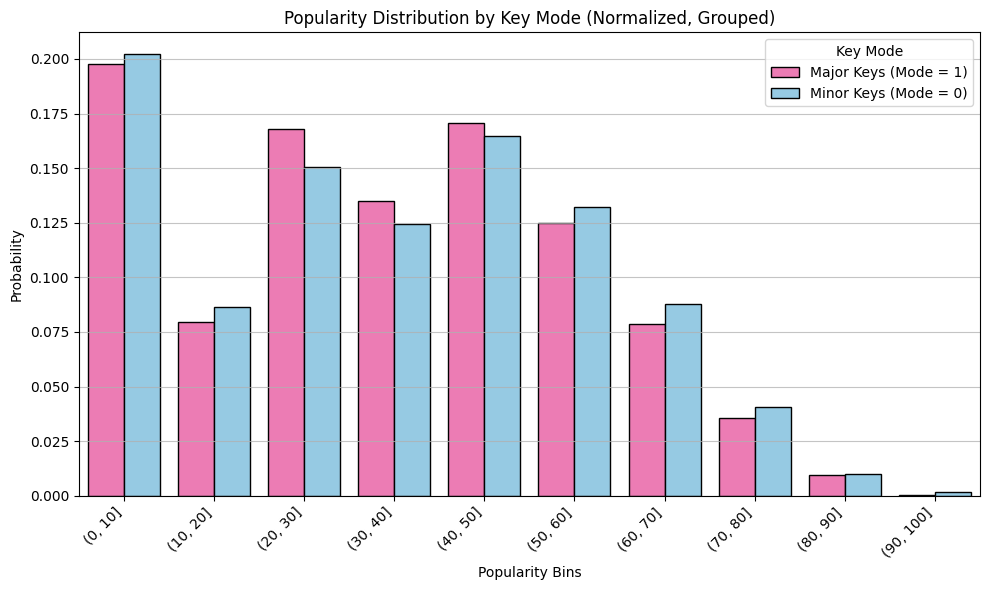

In [ ]:
import numpy as np
import pandas as pd # Import pandas for DataFrame creation

# Ensure filtered_df_mode_1 and filtered_df_mode_0 are available from previous steps
if 'df' in locals() and not df.empty:
    filtered_df_mode_1 = df[df['mode'] == 1]
    filtered_df_mode_0 = df[df['mode'] == 0]

    if not filtered_df_mode_1.empty and not filtered_df_mode_0.empty:
        plt.figure(figsize=(10, 6)) # Changed figure size to (10, 6) to match previous charts

        # Define common bins for popularity (0 to 100, 10 bins)
        common_bins = np.linspace(0, 100, 11)

        # Calculate histogram data for major keys
        counts_mode_1, _ = np.histogram(filtered_df_mode_1['popularity'], bins=common_bins)
        probs_mode_1 = counts_mode_1 / len(filtered_df_mode_1)

        # Calculate histogram data for minor keys
        counts_mode_0, _ = np.histogram(filtered_df_mode_0['popularity'], bins=common_bins)
        probs_mode_0 = counts_mode_0 / len(filtered_df_mode_0)

        # Prepare data for grouped bar plot
        bin_labels = []
        for i in range(len(common_bins) - 1):
            bin_labels.append(f"({common_bins[i]:.0f}, {common_bins[i+1]:.0f}]")

        plot_df = pd.DataFrame({
            'Popularity Bins': bin_labels * 2,
            'Probability': np.concatenate([probs_mode_1, probs_mode_0]),
            'Key Mode': ['Major Keys (Mode = 1)'] * len(probs_mode_1) + ['Minor Keys (Mode = 0)'] * len(probs_mode_0)
        })

        # Create the grouped bar plot
        sns.barplot(x='Popularity Bins', y='Probability', hue='Key Mode', data=plot_df,
                    palette={'Major Keys (Mode = 1)': '#FF69B4', 'Minor Keys (Mode = 0)': '#89CFF0'}, edgecolor='black')

        plt.title('Popularity Distribution by Key Mode (Normalized, Grouped)')
        plt.xlabel('Popularity Bins')
        plt.ylabel('Probability')
        plt.grid(axis='y', alpha=0.75)
        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
        plt.legend(title='Key Mode')

        plt.tight_layout()
        plt.show()
    else:
        print("No data found for one or both modes. Cannot generate grouped histogram.")
else:
    print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

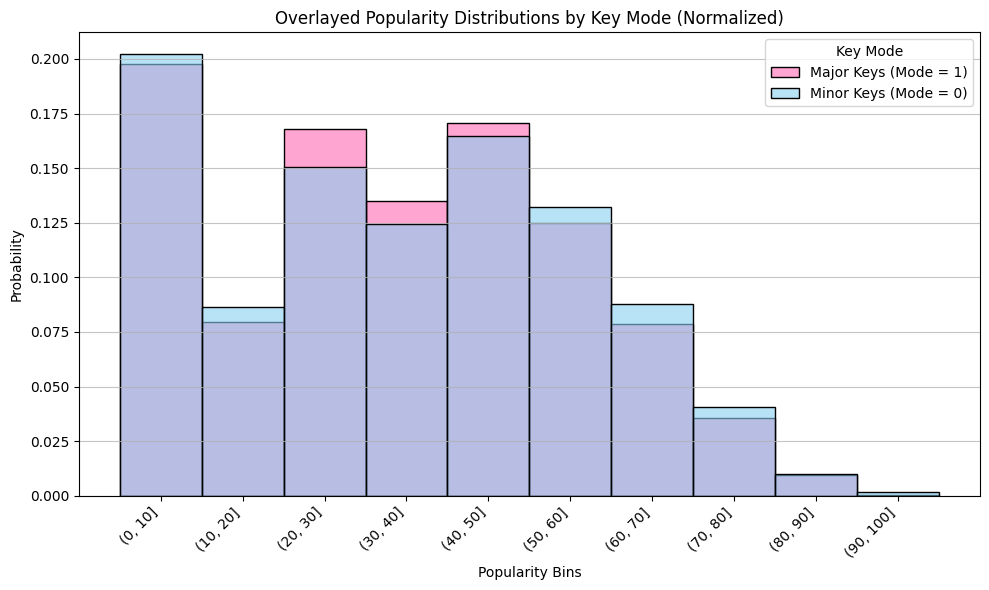

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure filtered_df_mode_1 and filtered_df_mode_0 are available from previous steps
if 'df' in locals() and not df.empty:
    filtered_df_mode_1 = df[df['mode'] == 1]
    filtered_df_mode_0 = df[df['mode'] == 0]

    if not filtered_df_mode_1.empty and not filtered_df_mode_0.empty:
        plt.figure(figsize=(10, 6)) # Changed figure size to (10, 6) to match previous charts

        # Define common bins for popularity (0 to 100, 10 bins)
        common_bins = np.linspace(0, 100, 11)

        # Plot histogram for Mode = 1 (Major Keys) - using probability for normalization
        sns.histplot(filtered_df_mode_1['popularity'], bins=common_bins, kde=False, color='#FF69B4',
                     stat='probability', label='Major Keys (Mode = 1)', alpha=0.6)

        # Plot histogram for Mode = 0 (Minor Keys) - using probability for normalization
        sns.histplot(filtered_df_mode_0['popularity'], bins=common_bins, kde=False, color='#89CFF0',
                     stat='probability', label='Minor Keys (Mode = 0)', alpha=0.6) # Baby blue color

        plt.title('Overlayed Popularity Distributions by Key Mode (Normalized)')
        plt.xlabel('Popularity Bins')
        plt.ylabel('Probability') # Changed ylabel to reflect normalization
        plt.grid(axis='y', alpha=0.75)
        plt.legend(title='Key Mode')

        # Format x-axis labels with open parentheses and closed brackets notation
        bin_labels = []
        for i in range(len(common_bins) - 1):
            bin_labels.append(f"({common_bins[i]:.0f}, {common_bins[i+1]:.0f}]")

        bin_centers = (common_bins[:-1] + common_bins[1:]) / 2
        plt.xticks(bin_centers, bin_labels, rotation=45, ha='right')

        plt.tight_layout()
        plt.show()
    else:
        print("No data found for one or both modes. Cannot generate overlayed histogram.")
else:
    print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

In [ ]:
import pandas as pd
import numpy as np

# Ensure df is loaded
if 'df' in locals() and not df.empty:
    filtered_df_mode_1 = df[df['mode'] == 1]
    filtered_df_mode_0 = df[df['mode'] == 0]

    if not filtered_df_mode_1.empty and not filtered_df_mode_0.empty:
        common_bins = np.linspace(0, 100, 11)

        # Probabilities for Major Keys
        counts_mode_1, _ = np.histogram(filtered_df_mode_1['popularity'], bins=common_bins)
        probs_mode_1 = counts_mode_1 / len(filtered_df_mode_1)

        # Probabilities for Minor Keys
        counts_mode_0, _ = np.histogram(filtered_df_mode_0['popularity'], bins=common_bins)
        probs_mode_0 = counts_mode_0 / len(filtered_df_mode_0)

        # Probabilities for Overall (all tracks)
        counts_overall, _ = np.histogram(df['popularity'], bins=common_bins)
        probs_overall = counts_overall / len(df)

        bin_labels = []
        for i in range(len(common_bins) - 1):
            bin_labels.append(f"({common_bins[i]:.0f}, {common_bins[i+1]:.0f}]")

        summary_table_df = pd.DataFrame({
            'Popularity bins': bin_labels,
            'Probability (Major)': probs_mode_1,
            'Probability (Minor)': probs_mode_0,
            'Probability (Overall)': probs_overall
        })

        # Round probability columns to 3 decimal places
        summary_table_df['Probability (Major)'] = summary_table_df['Probability (Major)'].round(3)
        summary_table_df['Probability (Minor)'] = summary_table_df['Probability (Minor)'].round(3)
        summary_table_df['Probability (Overall)'] = summary_table_df['Probability (Overall)'].round(3)

        # Display the table
        display(summary_table_df)
    else:
        print("No data found for one or both modes. Cannot generate the table.")
else:
    print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

,Popularity bins,Probability (Major),Probability (Minor),Probability (Overall)
0,"(0, 10]",0.198,0.202,0.199
1,"(10, 20]",0.079,0.086,0.082
2,"(20, 30]",0.168,0.151,0.162
3,"(30, 40]",0.135,0.124,0.131
4,"(40, 50]",0.171,0.165,0.169
5,"(50, 60]",0.125,0.132,0.128
6,"(60, 70]",0.079,0.088,0.082
7,"(70, 80]",0.036,0.040,0.037
8,"(80, 90]",0.009,0.010,0.010
9,"(90, 100]",0.000,0.002,0.001


Let's generate a popularity distribution histogram for all songs, not separated by key mode.

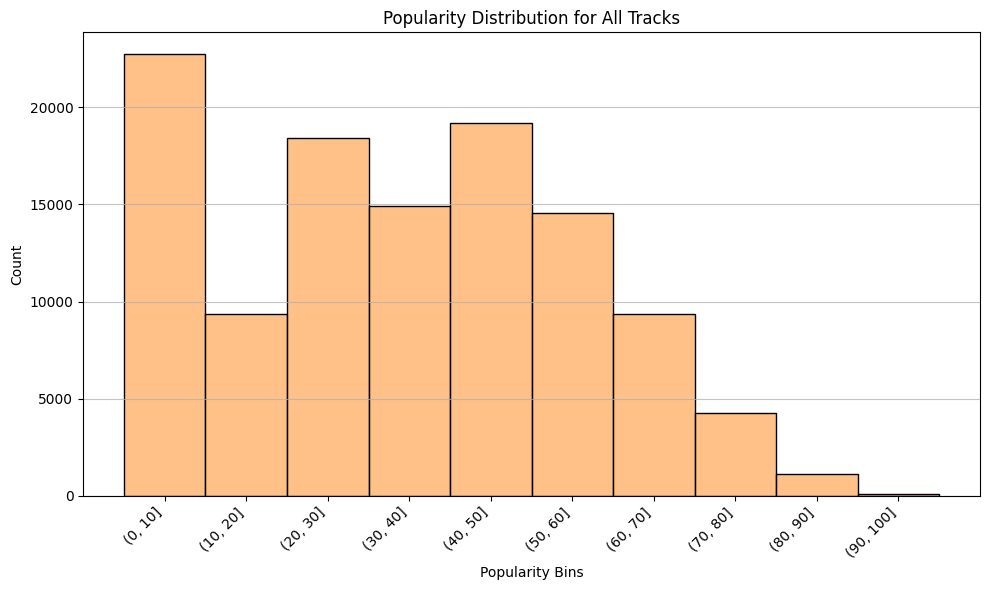

In [ ]:
# Ensure df is loaded
if 'df' in locals() and not df.empty:
  # Create a 10-bin histogram of 'popularity' for all songs
  plt.figure(figsize=(10, 6))

  # Calculate bin edges using numpy.histogram
  import numpy as np
  hist_values_all, bin_edges_all = np.histogram(df['popularity'], bins=10)

  # Plot the histogram
  sns.histplot(df['popularity'], bins=bin_edges_all, kde=False, color='#FFAD60') # Slightly lighter orange color

  plt.title('Popularity Distribution for All Tracks')
  plt.ylabel('Count')
  plt.grid(axis='y', alpha=0.75)

  # Format the x-axis labels with open parentheses and closed brackets notation
  bin_labels_all = []
  for i in range(len(bin_edges_all) - 1):
      # Format as (lower, upper]. Use .0f to avoid decimals if popularity is integer-like.
      bin_labels_all.append(f"({bin_edges_all[i]:.0f}, {bin_edges_all[i+1]:.0f}]")

  # Set x-ticks at the center of each bin for better label alignment with the bars
  bin_centers_all = (bin_edges_all[:-1] + bin_edges_all[1:]) / 2
  plt.xticks(bin_centers_all, bin_labels_all, rotation=45, ha='right')
  plt.xlabel('Popularity Bins')

  plt.tight_layout()
  plt.show()
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Let's create a grouped and normalized bar chart including Major Keys, Minor Keys, and the Overall popularity distribution.

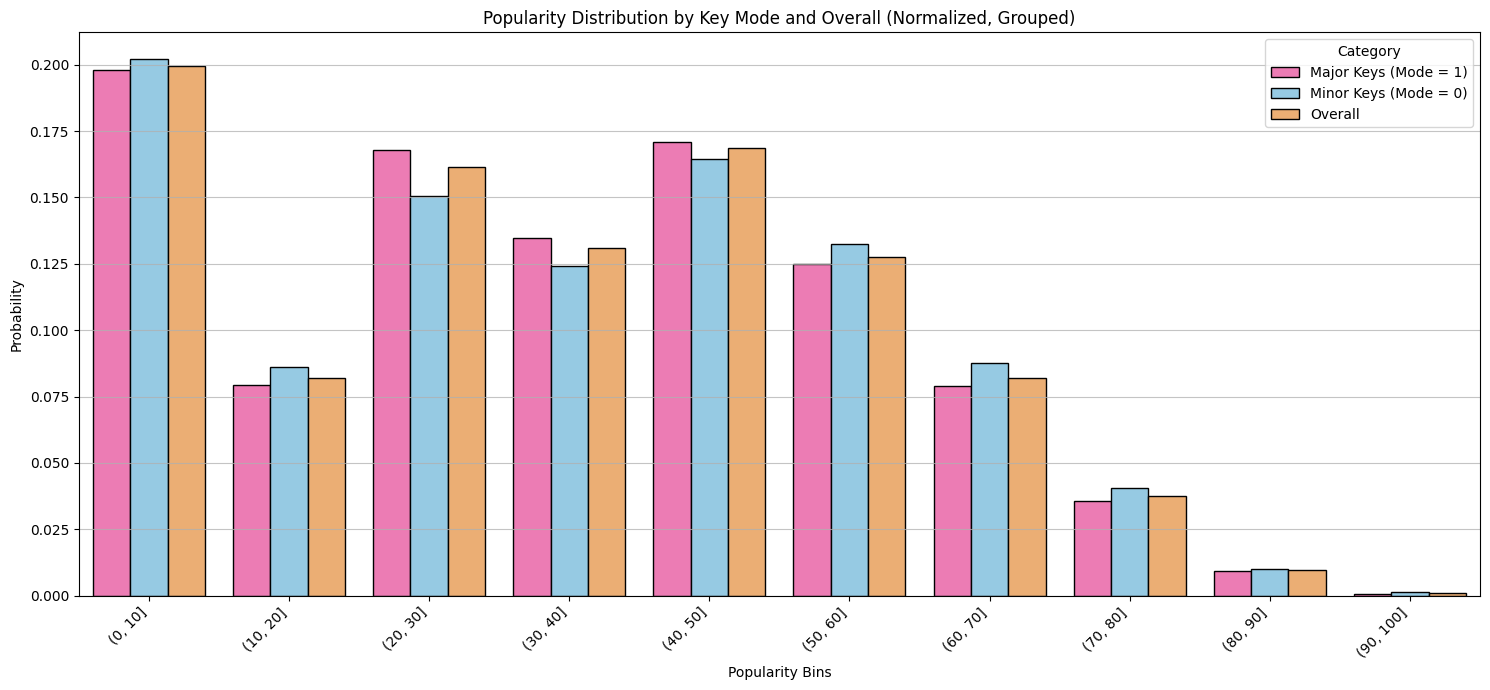

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and filtered_df_mode_1, filtered_df_mode_0 are available
if 'df' in locals() and not df.empty:
    filtered_df_mode_1 = df[df['mode'] == 1]
    filtered_df_mode_0 = df[df['mode'] == 0]

    if not filtered_df_mode_1.empty and not filtered_df_mode_0.empty:
        plt.figure(figsize=(15, 7)) # Adjust figure size for three groups

        # Define common bins for popularity (0 to 100, 10 bins)
        common_bins = np.linspace(0, 100, 11)

        # Calculate histogram data for Major Keys
        counts_mode_1, _ = np.histogram(filtered_df_mode_1['popularity'], bins=common_bins)
        probs_mode_1 = counts_mode_1 / len(filtered_df_mode_1)

        # Calculate histogram data for Minor Keys
        counts_mode_0, _ = np.histogram(filtered_df_mode_0['popularity'], bins=common_bins)
        probs_mode_0 = counts_mode_0 / len(filtered_df_mode_0)

        # Calculate histogram data for Overall (all tracks)
        counts_overall, _ = np.histogram(df['popularity'], bins=common_bins)
        probs_overall = counts_overall / len(df)

        # Prepare bin labels
        bin_labels = []
        for i in range(len(common_bins) - 1):
            bin_labels.append(f"({common_bins[i]:.0f}, {common_bins[i+1]:.0f}]")

        # Prepare data for grouped bar plot
        plot_df_full = pd.DataFrame({
            'Popularity Bins': bin_labels * 3,
            'Probability': np.concatenate([probs_mode_1, probs_mode_0, probs_overall]),
            'Key Mode': ['Major Keys (Mode = 1)'] * len(probs_mode_1) +
                        ['Minor Keys (Mode = 0)'] * len(probs_mode_0) +
                        ['Overall'] * len(probs_overall)
        })

        # Create the grouped bar plot
        sns.barplot(x='Popularity Bins', y='Probability', hue='Key Mode', data=plot_df_full,
                    palette={'Major Keys (Mode = 1)': '#FF69B4', 'Minor Keys (Mode = 0)': '#89CFF0', 'Overall': '#FFAD60'},
                    edgecolor='black')

        plt.title('Popularity Distribution by Key Mode and Overall (Normalized, Grouped)')
        plt.xlabel('Popularity Bins')
        plt.ylabel('Probability')
        plt.grid(axis='y', alpha=0.75)
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Category')

        plt.tight_layout()
        plt.show()
    else:
        print("No data found for one or more categories. Cannot generate grouped histogram.")
else:
    print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Let's run a statistical significance test to see if modality (major vs. minor keys) affects song popularity using an independent samples t-test.

In [ ]:
from scipy import stats

# Ensure df is loaded and filtered_df_mode_1, filtered_df_mode_0 are available
if 'df' in locals() and not df.empty:
    filtered_df_mode_1 = df[df['mode'] == 1]
    filtered_df_mode_0 = df[df['mode'] == 0]

    if not filtered_df_mode_1.empty and not filtered_df_mode_0.empty:
        # Extract popularity scores for each mode
        popularity_mode_1 = filtered_df_mode_1['popularity']
        popularity_mode_0 = filtered_df_mode_0['popularity']

        # Perform Levene's test for equality of variances (assumption for t-test)
        levene_statistic, levene_pvalue = stats.levene(popularity_mode_1, popularity_mode_0)
        print(f"Levene's Test for Equality of Variances: statistic={levene_statistic:.4f}, p-value={levene_pvalue:.4f}")

        # Perform independent samples t-test
        # 'equal_var=False' is used if Levene's test suggests unequal variances (p-value < 0.05)
        # For very large samples, slight deviations from normality or equal variance are often tolerated.
        # However, it's good practice to check and adjust.
        if levene_pvalue < 0.05:
            # Variances are unequal, use Welch's t-test
            t_statistic, p_value = stats.ttest_ind(popularity_mode_1, popularity_mode_0, equal_var=False)
            print("\nIndependent Samples t-test (Welch's t-test - unequal variances assumed):")
        else:
            # Variances are equal, use standard independent t-test
            t_statistic, p_value = stats.ttest_ind(popularity_mode_1, popularity_mode_0, equal_var=True)
            print("\nIndependent Samples t-test (standard t-test - equal variances assumed):")

        print(f"t-statistic={t_statistic:.4f}, p-value={p_value:.4f}")

        # Interpret the results
        alpha = 0.05
        print(f"Significance level (alpha) = {alpha}")
        if p_value < alpha:
            print("Conclusion: There is a statistically significant difference in popularity between songs in major and minor keys.")
        else:
            print("Conclusion: There is no statistically significant difference in popularity between songs in major and minor keys.")

        # Also print the mean popularity for each group for context
        print(f"\nMean popularity for Major Keys (Mode = 1): {popularity_mode_1.mean():.2f}")
        print(f"Mean popularity for Minor Keys (Mode = 0): {popularity_mode_0.mean():.2f}")
    else:
        print("No data found for one or both modes. Cannot perform statistical test.")
else:
    print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Levene's Test for Equality of Variances: statistic=76.1767, p-value=0.0000

Independent Samples t-test (Welch's t-test - unequal variances assumed):
t-statistic=-4.6709, p-value=0.0000
Significance level (alpha) = 0.05
Conclusion: There is a statistically significant difference in popularity between songs in major and minor keys.

Mean popularity for Major Keys (Mode = 1): 33.00
Mean popularity for Minor Keys (Mode = 0): 33.65


Let's normalize both 'energy' and 'danceability' to a 0-1 scale using Min-Max scaling, and then overlay their probability distributions to compare their shapes.

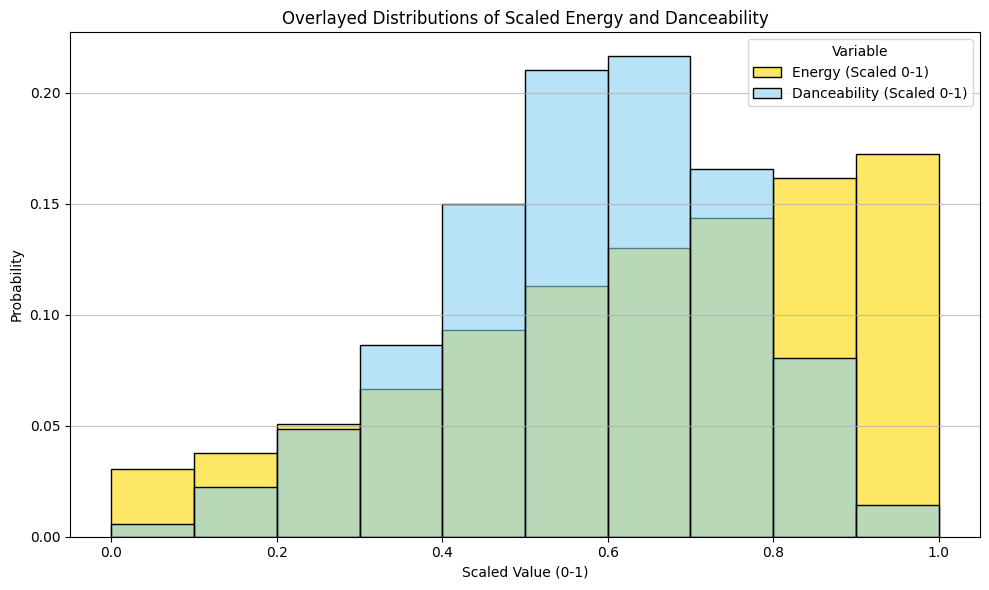

In [ ]:
from sklearn.preprocessing import MinMaxScaler

if 'df' in locals() and not df.empty:
  if 'energy' in df.columns and 'danceability' in df.columns:
    # Initialize MinMaxScaler
    scaler = MinMaxScaler()

    # Reshape data for scaling (MinMaxScaler expects 2D array)
    energy_scaled = scaler.fit_transform(df[['energy']])
    danceability_scaled = scaler.fit_transform(df[['danceability']])

    # Create a temporary DataFrame for plotting scaled data
    df_scaled_ed = pd.DataFrame({
        'energy_scaled': energy_scaled.flatten(),
        'danceability_scaled': danceability_scaled.flatten()
    })

    plt.figure(figsize=(10, 6))

    # Plot histogram for scaled Energy
    sns.histplot(df_scaled_ed['energy_scaled'], bins=10, kde=False, color='#FFD700',
                 stat='probability', label='Energy (Scaled 0-1)', alpha=0.6) # Gold color

    # Plot histogram for scaled Danceability
    sns.histplot(df_scaled_ed['danceability_scaled'], bins=10, kde=False, color='#89CFF0',
                 stat='probability', label='Danceability (Scaled 0-1)', alpha=0.6) # Baby blue color

    plt.title('Overlayed Distributions of Scaled Energy and Danceability')
    plt.xlabel('Scaled Value (0-1)')
    plt.ylabel('Probability')
    plt.grid(axis='y', alpha=0.75)
    plt.legend(title='Variable')
    plt.tight_layout()
    plt.show()
  else:
    print("One or both of the 'energy' or 'danceability' columns were not found in the DataFrame.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

Let's see the overlaid histogram of 'danceability' and 'energy' *without* normalizing the data to understand the difference in their original scales.

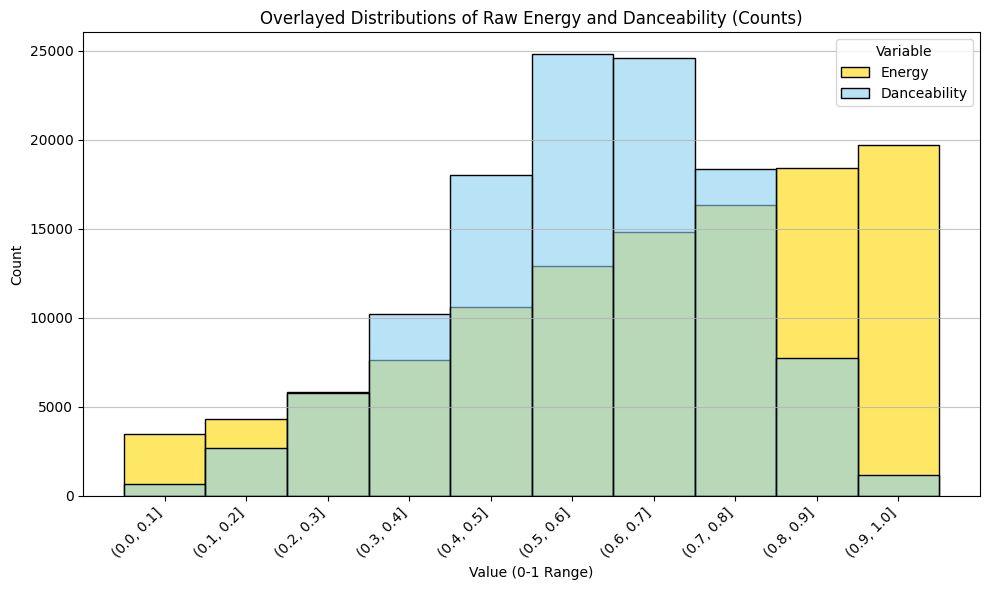

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if 'df' in locals() and not df.empty:
  if 'danceability' in df.columns and 'energy' in df.columns:
    plt.figure(figsize=(10, 6))

    # Define common bins for both variables (0 to 1, 10 bins)
    common_bins = np.linspace(0, 1, 11)

    # Plot histogram for Energy (without scaling, showing counts)
    sns.histplot(df['energy'], bins=common_bins, kde=False, color='#FFD700', # Gold color
                 stat='count', label='Energy', alpha=0.6)

    # Plot histogram for Danceability (without scaling, showing counts)
    sns.histplot(df['danceability'], bins=common_bins, kde=False, color='#89CFF0', # Baby blue color
                 stat='count', label='Danceability', alpha=0.6)

    plt.title('Overlayed Distributions of Raw Energy and Danceability (Counts)')
    plt.ylabel('Count')
    plt.grid(axis='y', alpha=0.75)
    plt.legend(title='Variable')

    # Format the x-axis labels with open parentheses and closed brackets notation
    bin_labels = []
    for i in range(len(common_bins) - 1):
        # Format as (lower, upper]. Use .1f to avoid excessive decimals.
        bin_labels.append(f"({common_bins[i]:.1f}, {common_bins[i+1]:.1f}]")

    # Set x-ticks at the center of each bin for better label alignment with the bars
    bin_centers = (common_bins[:-1] + common_bins[1:]) / 2
    plt.xticks(bin_centers, bin_labels, rotation=45, ha='right')
    plt.xlabel('Value (0-1 Range)') # Changed xlabel to reflect bins

    plt.tight_layout()
    plt.show()
  else:
    print("One or both of the 'energy' or 'danceability' columns were not found in the DataFrame.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

# Set the path to the file you'd like to load
file_path = "dataset.csv"

# Load the latest version of the dataset
try:
  df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "maharshipandya/-spotify-tracks-dataset",
    file_path
  )
  print(f"Dataset '{file_path}' loaded successfully. First 5 rows:\n")
  display(df.head())
except Exception as e:
  print(f"Error loading dataset: {e}")
  print("Please ensure the dataset 'maharshipandya/-spotify-tracks-dataset' is available and 'dataset.csv' (or the correct filename) is the correct file path.")

/tmp/ipykernel_671/1486355200.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Dataset 'dataset.csv' loaded successfully. First 5 rows:



,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


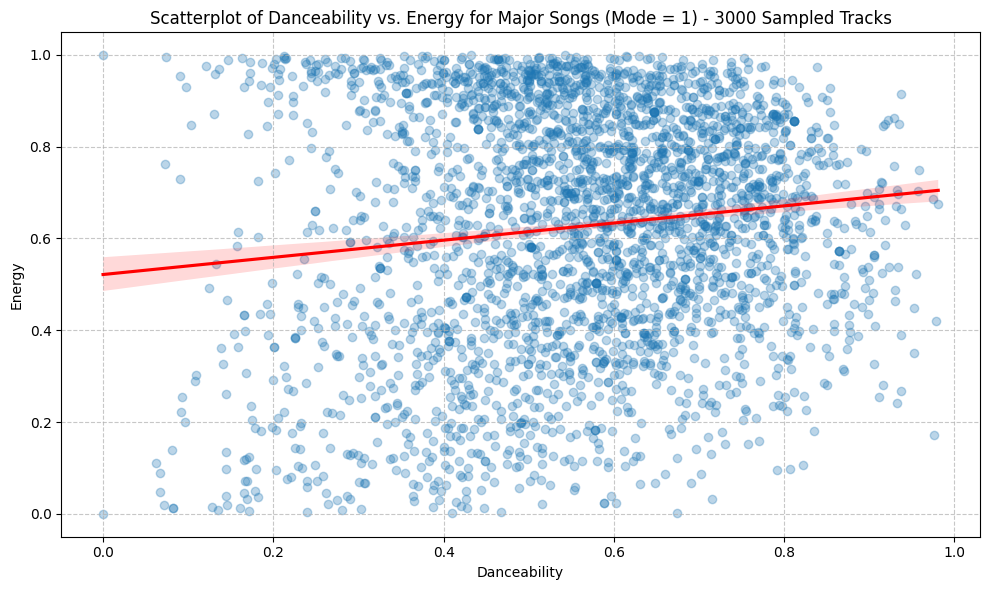

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and required columns exist
if 'df' in locals() and not df.empty:
  if 'danceability' in df.columns and 'energy' in df.columns and 'mode' in df.columns:

    # Filter for Major Keys (mode = 1)
    major_songs_df = df[df['mode'] == 1]
    # Sample 3000 tracks, or all if less than 3000
    if len(major_songs_df) > 3000:
        major_songs_sampled = major_songs_df.sample(n=3000, random_state=42)
    else:
        major_songs_sampled = major_songs_df

    plt.figure(figsize=(10, 6))
    sns.regplot(x='danceability', y='energy', data=major_songs_sampled,
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title('Scatterplot of Danceability vs. Energy for Major Songs (Mode = 1) - 3000 Sampled Tracks')
    plt.xlabel('Danceability')
    plt.ylabel('Energy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

  else:
    print("One or more of the 'danceability', 'energy', or 'mode' columns were not found in the DataFrame.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

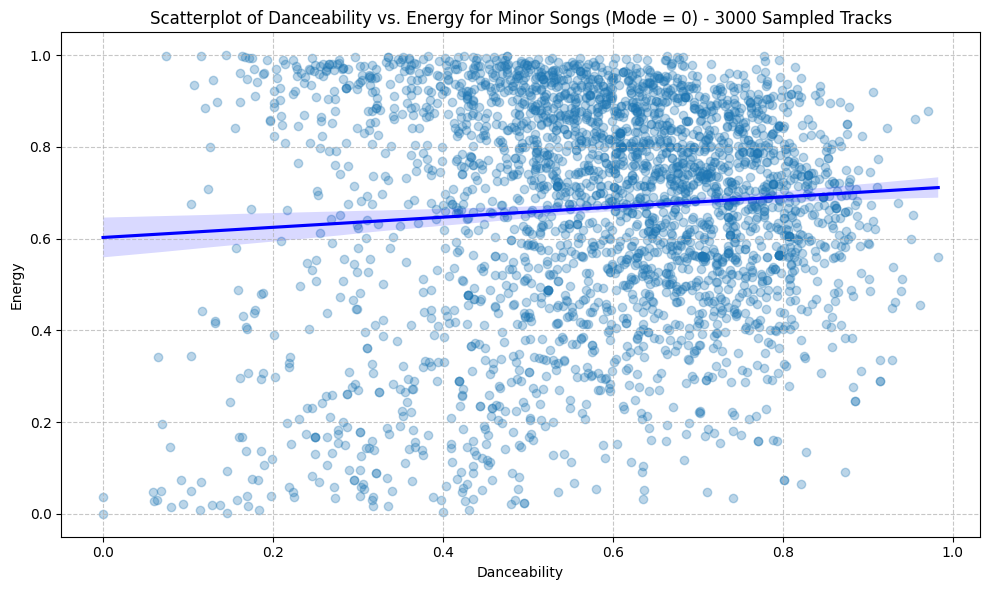

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and required columns exist
if 'df' in locals() and not df.empty:
  if 'danceability' in df.columns and 'energy' in df.columns and 'mode' in df.columns:

    # Filter for Minor Keys (mode = 0)
    minor_songs_df = df[df['mode'] == 0]
    # Sample 3000 tracks, or all if less than 3000
    if len(minor_songs_df) > 3000:
        minor_songs_sampled = minor_songs_df.sample(n=3000, random_state=42)
    else:
        minor_songs_sampled = minor_songs_df

    plt.figure(figsize=(10, 6))
    sns.regplot(x='danceability', y='energy', data=minor_songs_sampled,
                scatter_kws={'alpha':0.3}, line_kws={'color':'blue'})
    plt.title('Scatterplot of Danceability vs. Energy for Minor Songs (Mode = 0) - 3000 Sampled Tracks')
    plt.xlabel('Danceability')
    plt.ylabel('Energy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

  else:
    print("One or more of the 'danceability', 'energy', or 'mode' columns were not found in the DataFrame.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")

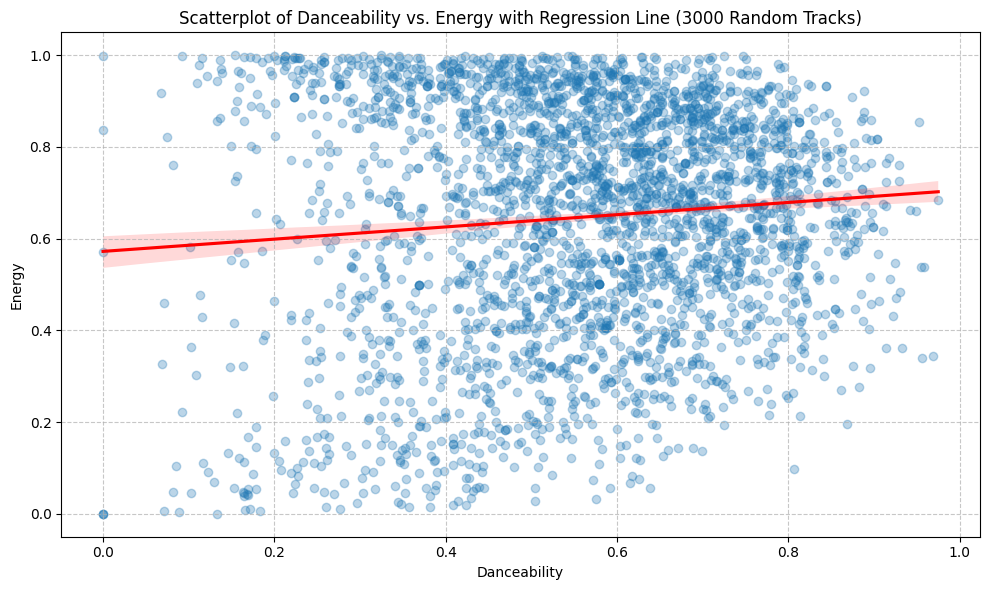

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df is loaded and 'danceability' and 'energy' columns exist
if 'df' in locals() and not df.empty:
  if 'danceability' in df.columns and 'energy' in df.columns:
    # Take 3000 random tracks
    df_sampled = df.sample(n=3000, random_state=42) # Using random_state for reproducibility

    plt.figure(figsize=(10, 6))

    # Create a scatterplot with a regression line using seaborn.regplot
    sns.regplot(x='danceability', y='energy', data=df_sampled,
                scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

    plt.title('Scatterplot of Danceability vs. Energy with Regression Line (3000 Random Tracks)')
    plt.xlabel('Danceability')
    plt.ylabel('Energy')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
  else:
    print("One or both of the 'danceability' or 'energy' columns were not found in the DataFrame.")
else:
  print("DataFrame 'df' not found or is empty. Please ensure the dataset was loaded correctly.")